# **Risk Factors**

In [1]:
import pandas as pd
import os

dfs = []

for filename in os.listdir():
    if filename.endswith(".csv"):
        df = pd.read_csv(filename)
        dfs.append(df)

In [2]:
#concat three files
data = pd.concat(dfs, ignore_index=True)

In [3]:
# shuffle data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)


In [4]:
data.head()

,id,age_years,gravidity,parity,gestational_age_weeks,bmi_pre_pregnancy,systolic_bp_mmhg,diastolic_bp_mmhg,hemoglobin_gdl,anemia_status,fasting_glucose_mgdl,proteinuria,hiv_status,anc_visits,delivery_mode,primary_complication,pregnancy_outcome,risk_level
0,2309,22,1,0,41.9,27.8,103,67,12.7,none,123,0,0,3,vaginal,gestational_diabetes,live_birth,moderate
1,2405,26,4,2,31.1,28.1,113,74,10.8,mild,103,1,0,3,vaginal,gestational_diabetes,live_birth,moderate
2,3398,29,2,0,27.5,17.5,109,67,11.1,none,82,0,0,1,vaginal,none,live_birth,low
3,5059,37,7,6,21.3,22.7,119,68,13.4,none,77,0,0,3,caesarean,none,live_birth,moderate
4,2665,15,1,0,17.8,20.5,120,71,13.7,none,76,0,0,3,vaginal,none,live_birth,high


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     30000 non-null  int64  
 1   age_years              30000 non-null  int64  
 2   gravidity              30000 non-null  int64  
 3   parity                 30000 non-null  int64  
 4   gestational_age_weeks  30000 non-null  float64
 5   bmi_pre_pregnancy      30000 non-null  float64
 6   systolic_bp_mmhg       30000 non-null  int64  
 7   diastolic_bp_mmhg      30000 non-null  int64  
 8   hemoglobin_gdl         30000 non-null  float64
 9   anemia_status          30000 non-null  object 
 10  fasting_glucose_mgdl   30000 non-null  int64  
 11  proteinuria            30000 non-null  int64  
 12  hiv_status             30000 non-null  int64  
 13  anc_visits             30000 non-null  int64  
 14  delivery_mode          30000 non-null  object 
 15  pr

In [6]:
data.isnull().sum()

id                       0
age_years                0
gravidity                0
parity                   0
gestational_age_weeks    0
bmi_pre_pregnancy        0
systolic_bp_mmhg         0
diastolic_bp_mmhg        0
hemoglobin_gdl           0
anemia_status            0
fasting_glucose_mgdl     0
proteinuria              0
hiv_status               0
anc_visits               0
delivery_mode            0
primary_complication     0
pregnancy_outcome        0
risk_level               0
dtype: int64

THE DATA IS CLEANED

# **EDA**

In [7]:
data.describe()

,id,age_years,gravidity,parity,gestational_age_weeks,bmi_pre_pregnancy,systolic_bp_mmhg,diastolic_bp_mmhg,hemoglobin_gdl,fasting_glucose_mgdl,proteinuria,hiv_status,anc_visits
count,30000.000000,30000.000000,30000.0000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,5000.500000,26.049533,3.1750,2.070533,27.357543,23.706320,116.223467,72.681967,10.329173,84.929933,0.407833,0.100967,3.896133
std,2886.799445,5.521126,2.2361,2.211498,7.227483,4.289351,15.924999,11.022450,2.033087,12.085618,0.930126,0.301290,2.241275
min,1.000000,15.000000,1.0000,0.000000,6.000000,14.000000,72.000000,45.000000,3.100000,49.000000,0.000000,0.000000,0.000000
25%,2500.750000,22.000000,1.0000,0.000000,22.300000,20.600000,106.000000,66.000000,8.800000,77.000000,0.000000,0.000000,2.000000
50%,5000.500000,26.000000,3.0000,1.000000,27.600000,23.600000,114.000000,71.000000,10.600000,83.000000,0.000000,0.000000,4.000000
75%,7500.250000,30.000000,4.0000,3.000000,32.700000,26.600000,122.000000,77.000000,11.900000,90.000000,0.000000,0.000000,5.000000
max,10000.000000,47.000000,16.0000,15.000000,42.000000,39.800000,208.000000,133.000000,15.800000,165.000000,4.000000,1.000000,15.000000


In [8]:
#libraries
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [9]:

fig = px.histogram(data, x='risk_level', color='risk_level', text_auto=True,
                   title='Risk Level Distribution')
fig.show()

In [10]:
import plotly.express as px

fig = px.histogram(
    data,
    x="age_years",
    color="risk_level",
    nbins=30,
    barmode="overlay",
    title="Age Distribution by Risk Level"
)

fig.show()

In [11]:
fig = px.box(
    df,
    x="risk_level",
    y="age_years",
    color="risk_level",
    title="Age vs Pregnancy Risk Level"
)

fig.show()

In [12]:

fig = px.histogram(data, x='hemoglobin_gdl', nbins=50, marginal="box",
                   title='Hemoglobin Distribution')
fig.add_vline(x=11, line_dash="dash", line_color="orange", annotation_text="Anemia <11 g/dL")
fig.add_vline(x=7, line_dash="dash", line_color="red", annotation_text="Severe <7 g/dL")
fig.show()

In [13]:
fig = px.box(df, x="risk_level", y="systolic_bp_mmhg",
             color="risk_level",
             points="all",
             title="Systolic Blood Pressure vs Risk Level")
fig.show()

In [14]:
fig = px.scatter(df, x="fasting_glucose_mgdl", y="hemoglobin_gdl",
                 color="risk_level",
                 size="age_years",
                 hover_data=['anemia_status', 'proteinuria'],
                 title="Glucose vs Hemoglobin (Colored by Risk)")
fig.show()

In [15]:
fig = px.box(
    df,
    x="risk_level",
    y="bmi_pre_pregnancy",
    color="risk_level",
    title="BMI vs Risk Level"
)

fig.show()

In [16]:
fig = px.box(
    df,
    x="risk_level",
    y="fasting_glucose_mgdl",
    color="risk_level",
    title="Glucose Level vs Risk Level"
)

fig.show()

In [17]:
fig = px.box(
    df,
    x="risk_level",
    y="hemoglobin_gdl",
    color="risk_level",
    title="Hemoglobin Level vs Risk Level"
)

fig.show()

In [18]:
fig = px.histogram(
    df,
    x="primary_complication",
    color="risk_level",
    title="Distribution of Pregnancy Complications"
)

fig.show()

In [19]:
import pandas as pd
import plotly.express as px

df_high = pd.read_csv('maternal_high_burden.csv')
df_low = pd.read_csv('maternal_low_burden.csv')
df_mod = pd.read_csv('maternal_moderate_burden.csv')
df = pd.concat([df_high, df_low, df_mod], ignore_index=True)

df_encoded = df.copy()


anemia_map = {'none': 0, 'mild': 1, 'moderate': 2, 'severe': 3}
risk_map = {'low': 0, 'moderate': 1, 'high': 2}

df_encoded['anemia_status'] = df_encoded['anemia_status'].map(anemia_map)
df_encoded['risk_level'] = df_encoded['risk_level'].map(risk_map)


categorical_cols = ['delivery_mode', 'primary_complication', 'pregnancy_outcome']
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)


corr_matrix = df_encoded.drop(columns=['id']).corr()


fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale='RdBu_r',
    title="Maternal Health Factors Correlation Heatmap",
    labels=dict(color="Correlation Score")
)

fig.update_layout(
    width=1000,
    height=800,
    xaxis_tickangle=-45
)

fig.show()

# **data encoding**

In [20]:
df_fe= df.copy()

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_fe["risk_level"] = le.fit_transform(df_fe["risk_level"])

In [22]:
if 'anemia_status' in df_fe.columns:
    df_fe['anemia_status'] = le.fit_transform(df_fe['anemia_status'].astype(str))
    print("Encoded anemia_status classes:", list(le.classes_))

Encoded anemia_status classes: ['mild', 'moderate', 'none', 'severe']


# **Feature engineering**

In [23]:
df_fe['MAP'] = (df_fe['systolic_bp_mmhg'] + 2 * df_fe['diastolic_bp_mmhg']) / 3

In [24]:
df_fe['glucose_gestation'] = df_fe['fasting_glucose_mgdl'] * df_fe['gestational_age_weeks']

In [25]:
df_fe['is_high_risk_age'] = df_fe['age_years'].apply(lambda x: 1 if x < 18 or x > 35 else 0)

In [26]:
df_fe['risk_index'] = df_fe['MAP'] * df_fe['fasting_glucose_mgdl']

In [27]:
df_fe.head()

,id,age_years,gravidity,parity,gestational_age_weeks,bmi_pre_pregnancy,systolic_bp_mmhg,diastolic_bp_mmhg,hemoglobin_gdl,anemia_status,...,hiv_status,anc_visits,delivery_mode,primary_complication,pregnancy_outcome,risk_level,MAP,glucose_gestation,is_high_risk_age,risk_index
0,1,23,3,2,33.7,24.7,121,80,10.9,0,...,0,6,vaginal,none,live_birth,1,93.666667,2527.5,0,7025.000000
1,2,28,5,4,31.0,15.4,103,68,10.5,0,...,0,4,vaginal,none,live_birth,1,79.666667,2294.0,0,5895.333333
2,3,20,3,1,24.5,29.9,117,65,12.5,2,...,1,5,vaginal,none,live_birth,0,82.333333,2082.5,0,6998.333333
3,4,31,2,1,33.5,23.0,131,99,12.9,2,...,0,4,vaginal,preeclampsia,live_birth,2,109.666667,2914.5,0,9541.000000
4,5,32,9,8,22.3,25.4,159,90,12.3,2,...,0,4,vaginal,preeclampsia,live_birth,2,113.000000,1717.1,0,8701.000000


In [28]:
cols_to_drop = [
    'id',
    'pregnancy_outcome',
    'delivery_mode',
    'primary_complication' ,"gravidity","anemia_status"]

df_fe= df_fe.drop(columns=cols_to_drop , errors='ignore')


print("Final Features List:")
print(df_fe.columns.tolist())

Final Features List:
['age_years', 'parity', 'gestational_age_weeks', 'bmi_pre_pregnancy', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'hemoglobin_gdl', 'fasting_glucose_mgdl', 'proteinuria', 'hiv_status', 'anc_visits', 'risk_level', 'MAP', 'glucose_gestation', 'is_high_risk_age', 'risk_index']


# **MODELING**

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X = df_fe.drop("risk_level", axis=1)
y = df_fe["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

              precision    recall  f1-score   support

           0       0.56      0.58      0.57      1468
           1       0.74      0.84      0.78      2420
           2       0.60      0.49      0.54      2112

    accuracy                           0.65      6000
   macro avg       0.63      0.64      0.63      6000
weighted avg       0.65      0.65      0.65      6000



C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


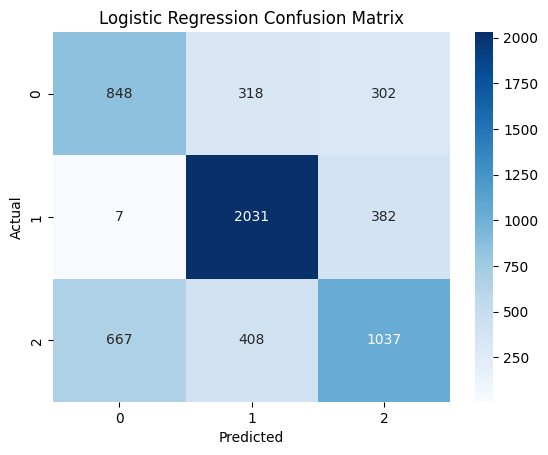

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logreg_model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight={0:1, 1:0.8, 2:0.8},
    random_state=42
)

logreg_model.fit(X_train, y_train)
y_pred = logreg_model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# RandomForest

with SMOTE

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Accuracy: 0.9336666666666666
              precision    recall  f1-score   support

           0       0.98      0.84      0.91      1468
           1       0.96      0.99      0.97      2420
           2       0.88      0.94      0.91      2112

    accuracy                           0.93      6000
   macro avg       0.94      0.92      0.93      6000
weighted avg       0.94      0.93      0.93      6000



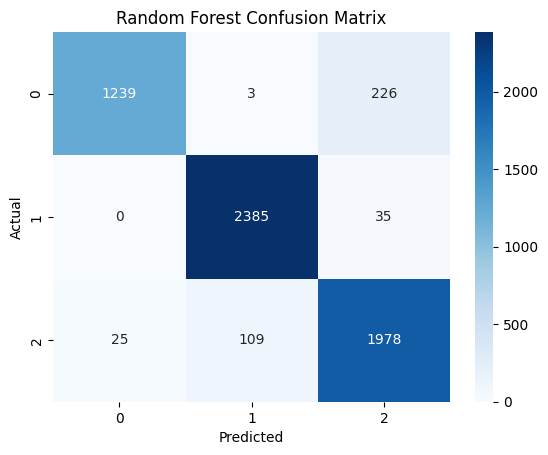

In [32]:
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))


cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [33]:
print(rf_model.feature_names_in_)

['age_years' 'parity' 'gestational_age_weeks' 'bmi_pre_pregnancy'
 'systolic_bp_mmhg' 'diastolic_bp_mmhg' 'hemoglobin_gdl'
 'fasting_glucose_mgdl' 'proteinuria' 'hiv_status' 'anc_visits' 'MAP'
 'glucose_gestation' 'is_high_risk_age' 'risk_index']



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      1468
           1       0.96      0.99      0.97      2420
           2       0.88      0.95      0.91      2112

    accuracy                           0.94      6000
   macro avg       0.94      0.92      0.93      6000
weighted avg       0.94      0.94      0.94      6000



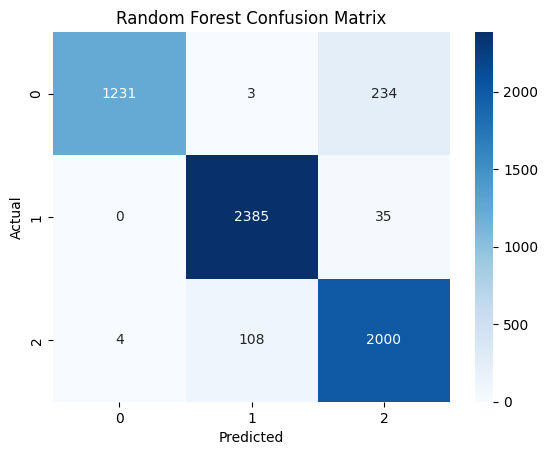

In [38]:


le = LabelEncoder()

r_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    class_weight='balanced'
)

r_model.fit(X_train, y_train)


y_pred = r_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

m = confusion_matrix(y_test, y_pred)

sns.heatmap(m, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [35]:
print(r_model.feature_names_in_)

['age_years' 'parity' 'gestational_age_weeks' 'bmi_pre_pregnancy'
 'systolic_bp_mmhg' 'diastolic_bp_mmhg' 'hemoglobin_gdl'
 'fasting_glucose_mgdl' 'proteinuria' 'hiv_status' 'anc_visits' 'MAP'
 'glucose_gestation' 'is_high_risk_age' 'risk_index']


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1720
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 15
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Accuracy: 0.9348

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      1468
           1       0.95      0.98      0.97      2420
           2       0.88      0.94      0.91      2112

    accuracy                           0.93      6000
   macro avg       0.94      0.92      0.93      6000
weighted avg       0.94      0.93      0.93      6000



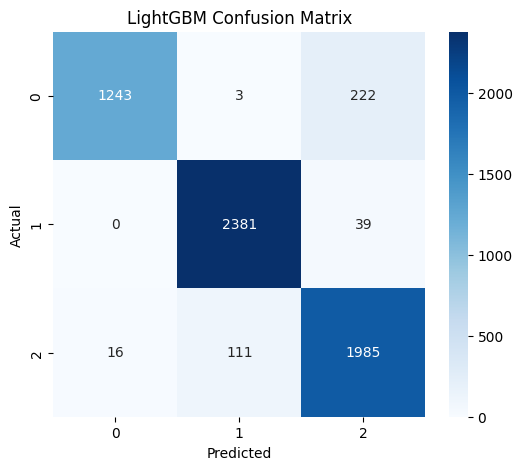

In [46]:
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Model
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=12,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced'
)

# Training
lgbm_model.fit(X_train, y_train)

# Prediction
y_pred = lgbm_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")

plt.show()

Random forest best accuracy

In [36]:
import joblib
joblib.dump(r_model, "model.pkl")

['model.pkl']